In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [19]:
df = pd.read_csv("../data/raw/ObesityDataSet.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [36]:
target = "NObeyesdad"

X = df.drop(columns=target)
y = df[target]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [61]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

C:\Users\torre\AppData\Local\Temp\ipykernel_13144\1397757656.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


In [62]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)
baseline_preds = baseline_pipeline.predict(X_test)

print("Baseline accuracy:", accuracy_score(y_test, baseline_preds))

Baseline accuracy: 0.8747044917257684


In [63]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [64]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softmax",
        eval_metric="mlogloss",
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_f1 = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

xgb_cv_f1 = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("RF CV F1 weighted:", rf_cv_f1)
print("RF Mean CV F1:", rf_cv_f1.mean())

print("XGB CV F1 weighted:", xgb_cv_f1)
print("XGB Mean CV F1:", xgb_cv_f1.mean())

RF CV F1 weighted: [0.93328451 0.94162021 0.91500547 0.92612012 0.89620967]
RF Mean CV F1: 0.922447996920144
XGB CV F1 weighted: [0.97344279 0.97931919 0.96732963 0.96147882 0.97011862]
XGB Mean CV F1: 0.9703378093701414


In [48]:
rf_search_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=rf_search_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_weighted",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV score:", rf_search.best_score_)

Best params: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}
Best CV score: 0.9349372484323288


In [49]:
best_model = rf_search.best_estimator_

In [50]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    return {
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "overfitting_gap": train_acc - test_acc,
        "precision_weighted": precision_score(y_test, y_pred_test, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred_test, average="weighted"),
        "f1_weighted": f1_score(y_test, y_pred_test, average="weighted")
    }

In [51]:
results = []

results.append(evaluate_model("Baseline Logistic", baseline_pipeline, X_train, X_test, y_train, y_test))
results.append(evaluate_model("Random Forest", rf_pipeline, X_train, X_test, y_train, y_test))
results.append(evaluate_model("XGBoost", xgb_pipeline, X_train, X_test, y_train, y_test))
results.append(evaluate_model("Tuned Random Forest", best_model, X_train, X_test, y_train, y_test))

results_df = pd.DataFrame(results).sort_values(by="f1_weighted", ascending=False)
results_df

,model,train_accuracy,test_accuracy,overfitting_gap,precision_weighted,recall_weighted,f1_weighted
2,XGBoost,1.000000,0.959811,0.040189,0.961976,0.959811,0.960209
3,Tuned Random Forest,0.991706,0.931442,0.060264,0.936503,0.931442,0.933022
1,Random Forest,0.985190,0.924350,0.060840,0.929706,0.924350,0.925843
0,Baseline Logistic,0.907583,0.874704,0.032878,0.872904,0.874704,0.873101


In [52]:
results_df["overfitting_ok"] = results_df["overfitting_gap"] < 0.05
results_df

,model,train_accuracy,test_accuracy,overfitting_gap,precision_weighted,recall_weighted,f1_weighted,overfitting_ok
2,XGBoost,1.000000,0.959811,0.040189,0.961976,0.959811,0.960209,True
3,Tuned Random Forest,0.991706,0.931442,0.060264,0.936503,0.931442,0.933022,False
1,Random Forest,0.985190,0.924350,0.060840,0.929706,0.924350,0.925843,False
0,Baseline Logistic,0.907583,0.874704,0.032878,0.872904,0.874704,0.873101,True


In [53]:
final_model = best_model
y_pred_final = final_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred_final,
    target_names=label_encoder.classes_
))

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.75      0.88      0.81        58
     Obesity_Type_I       0.96      0.96      0.96        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.88      0.84      0.86        58
Overweight_Level_II       0.96      0.91      0.94        58

           accuracy                           0.93       423
          macro avg       0.94      0.93      0.93       423
       weighted avg       0.94      0.93      0.93       423



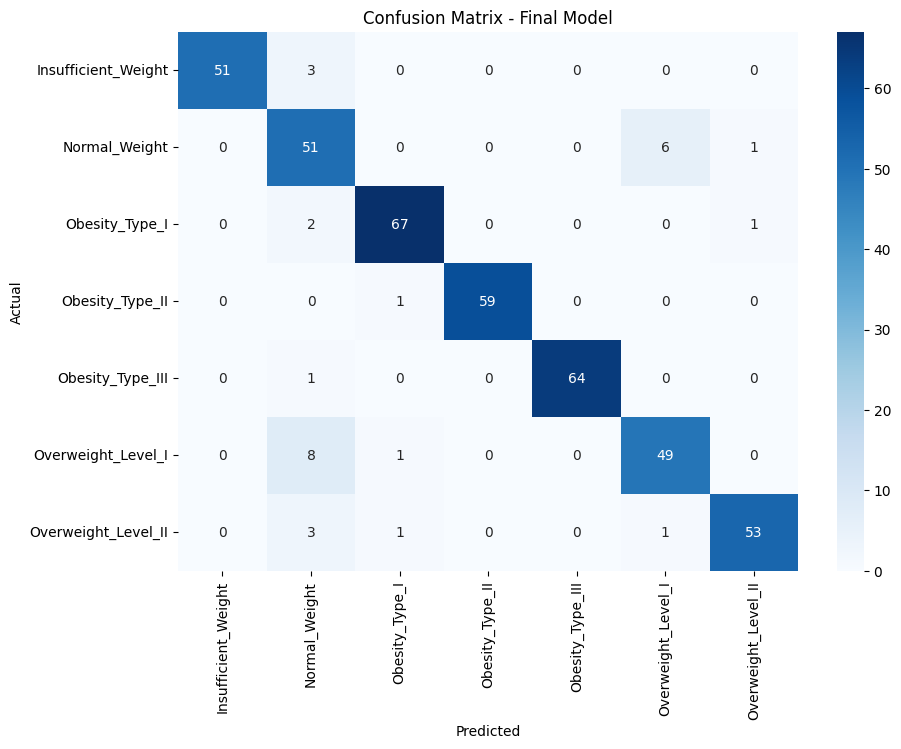

In [54]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

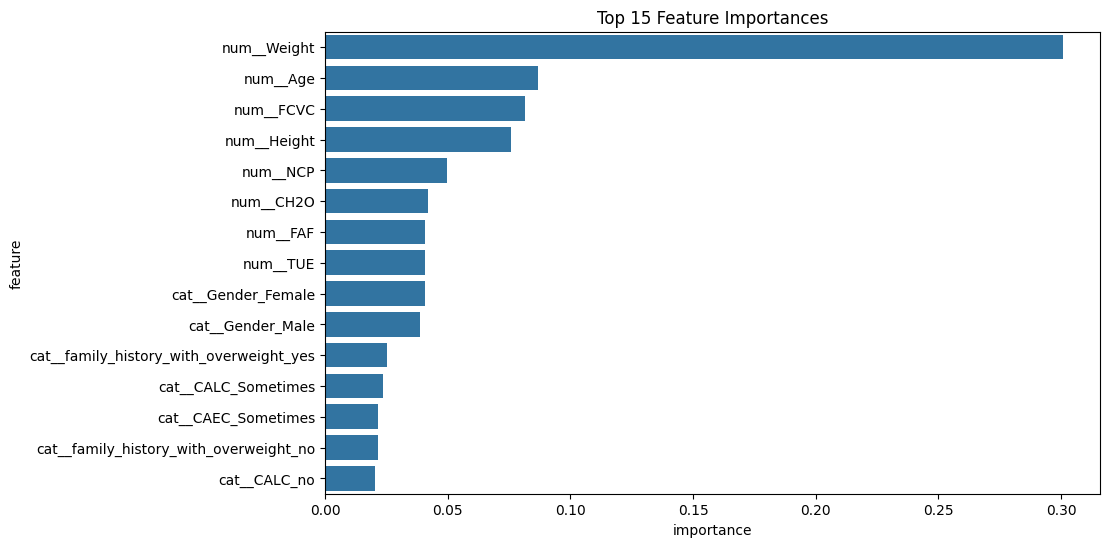

In [55]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values(by="importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="importance", y="feature")
plt.title("Top 15 Feature Importances")
plt.show()

In [56]:
pred_df = X_test.copy()
pred_df["actual"] = label_encoder.inverse_transform(y_test)
pred_df["predicted"] = label_encoder.inverse_transform(y_pred_final)
pred_df["correct"] = pred_df["actual"] == pred_df["predicted"]

errors_df = pred_df[pred_df["correct"] == False]
errors_df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,actual,predicted,correct
344,Male,18.0,1.87,173.0,yes,yes,3.0,3.0,Frequently,no,2.0,no,2.0,1.0,Sometimes,Public_Transportation,Obesity_Type_III,Normal_Weight,False
127,Female,19.0,1.65,61.0,no,yes,3.0,1.0,Sometimes,no,3.0,yes,1.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Overweight_Level_I,False
261,Female,28.0,1.70,73.0,yes,no,2.0,3.0,Frequently,no,2.0,yes,2.0,0.0,Sometimes,Walking,Overweight_Level_I,Normal_Weight,False
472,Female,18.0,1.54,71.0,no,no,3.0,4.0,Frequently,no,2.0,no,1.0,1.0,no,Public_Transportation,Overweight_Level_II,Normal_Weight,False
291,Male,17.0,1.80,58.0,no,yes,2.0,3.0,Frequently,no,2.0,no,2.0,1.0,no,Walking,Insufficient_Weight,Normal_Weight,False


In [57]:
errors_df["actual"].value_counts()

actual
Overweight_Level_I     9
Normal_Weight          7
Overweight_Level_II    5
Insufficient_Weight    3
Obesity_Type_I         3
Obesity_Type_III       1
Obesity_Type_II        1
Name: count, dtype: int64

In [59]:
joblib.dump(final_model, "../models/final_model.joblib")
joblib.dump(label_encoder, "../models/label_encoder.joblib")

['../models/label_encoder.joblib']